In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("diabetes.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
target = "BMI"

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features]
y = df[target]

print("Target Variable:", target)
print("\nPredictor Variables:")
for feature in features:
    print("-", feature)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Target Variable: BMI

Predictor Variables:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- DiabetesPedigreeFunction
- Age

Shape of X: (768, 7)
Shape of y: (768,)


In [6]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values in selected variables:\n")

for column in invalid_columns:
    print(column, ":", (df[column] == 0).sum())

Zero values in selected variables:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [7]:
df_clean = df.copy()

for column in invalid_columns:
    df_clean[column] = df_clean[column].replace(0, np.nan)

print("Missing values after replacing invalid zeros:\n")
print(df_clean[invalid_columns].isnull().sum())

Missing values after replacing invalid zeros:

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [8]:
for column in invalid_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("Missing values after median imputation:\n")
print(df_clean[invalid_columns].isnull().sum())

Missing values after median imputation:

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [9]:
X = df_clean[features]
y = df_clean["BMI"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst five predictor rows:")
display(X.head())

print("\nFirst five target values:")
display(y.head())

Features shape: (768, 7)
Target shape: (768,)

First five predictor rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,0.627,50
1,1,85.0,66.0,29.0,125.0,0.351,31
2,8,183.0,64.0,29.0,125.0,0.672,32
3,1,89.0,66.0,23.0,94.0,0.167,21
4,0,137.0,40.0,35.0,168.0,2.288,33



First five target values:


0    33.6
1    26.6
2    23.3
3    28.1
4    43.1
Name: BMI, dtype: float64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

print("\nTraining target size:", y_train.shape)
print("Testing target size:", y_test.shape)

Training set size: (614, 7)
Testing set size: (154, 7)

Training target size: (614,)
Testing target size: (154,)


In [11]:
model = LinearRegression()

print("Multiple Linear Regression model created successfully!")

Multiple Linear Regression model created successfully!


In [12]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
print("Regression Coefficients:\n")

for feature, coefficient in zip(features, model.coef_):
    print(f"{feature}: {coefficient:.4f}")

print("\nIntercept:", round(model.intercept_, 4))

Regression Coefficients:

Pregnancies: -0.0067
Glucose: 0.0295
BloodPressure: 0.1088
SkinThickness: 0.4244
Insulin: 0.0040
DiabetesPedigreeFunction: 1.6270
Age: -0.0890

Intercept: 10.3451


In [14]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predictions:
[31.13832868 34.24670702 31.67491763 33.3239481  32.79992311 31.14397106
 24.16489507 32.03603466 32.76331153 30.51021187]


In [15]:
comparison = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred
})

comparison["Residual"] = (
    comparison["Actual BMI"] -
    comparison["Predicted BMI"]
)

comparison.head(10)

,Actual BMI,Predicted BMI,Residual
0,34.0,31.138329,2.861671
1,35.7,34.246707,1.453293
2,30.8,31.674918,-0.874918
3,24.6,33.323948,-8.723948
4,29.9,32.799923,-2.899923
5,37.7,31.143971,6.556029
6,20.4,24.164895,-3.764895
7,33.8,32.036035,1.763965
8,31.3,32.763312,-1.463312
9,33.7,30.510212,3.189788


In [16]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 4))

Mean Absolute Error (MAE): 4.3867


In [17]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 4))

Mean Squared Error (MSE): 34.7884


In [18]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", round(rmse, 4))

Root Mean Squared Error (RMSE): 5.8982


In [19]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 4))
print("R² Score (%):", round(r2 * 100, 2), "%")

R² Score: 0.2046
R² Score (%): 20.46 %


In [20]:
print("=" * 45)
print("REGRESSION MODEL PERFORMANCE")
print("=" * 45)

print(f"Mean Absolute Error (MAE):  {mae:.4f}")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error:    {rmse:.4f}")
print(f"R² Score:                   {r2:.4f}")
print(f"R² Score (%):               {r2 * 100:.2f}%")

print("=" * 45)

REGRESSION MODEL PERFORMANCE
Mean Absolute Error (MAE):  4.3867
Mean Squared Error (MSE):   34.7884
Root Mean Squared Error:    5.8982
R² Score:                   0.2046
R² Score (%):               20.46%


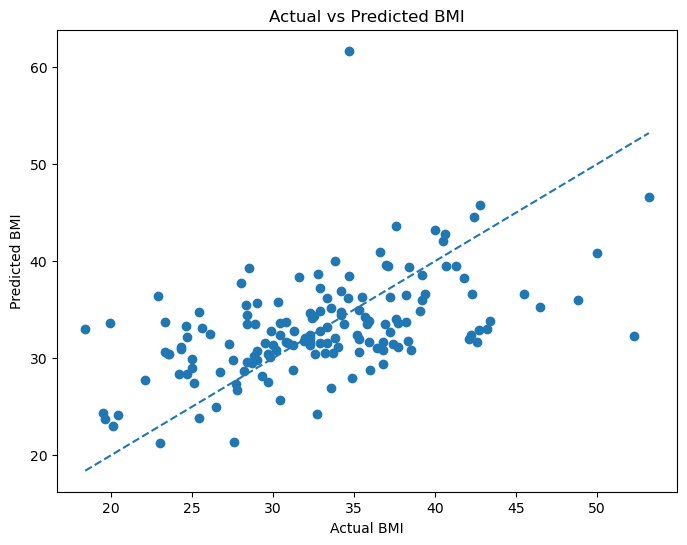

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [22]:
residuals = y_test - y_pred

print("First 10 Residuals:")
print(residuals[:10].values)

print("\nMean Residual:",
      residuals.mean())

First 10 Residuals:
[ 2.86167132  1.45329298 -0.87491763 -8.7239481  -2.89992311  6.55602894
 -3.76489507  1.76396534 -1.46331153  3.18978813]

Mean Residual: -0.25931824849822477


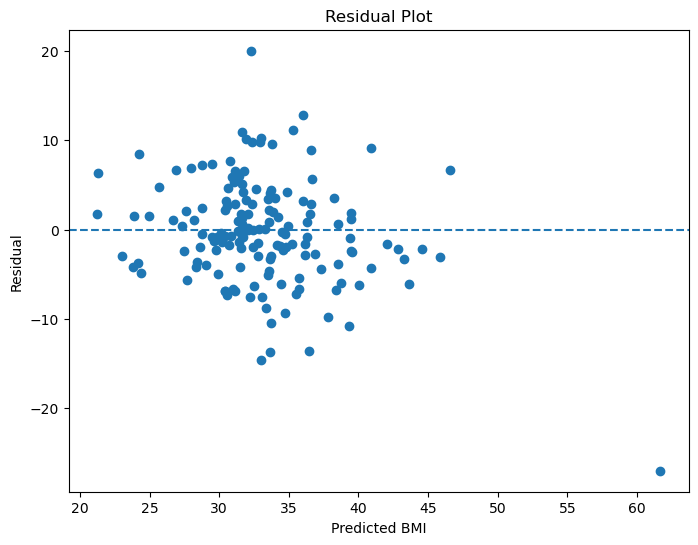

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted BMI")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

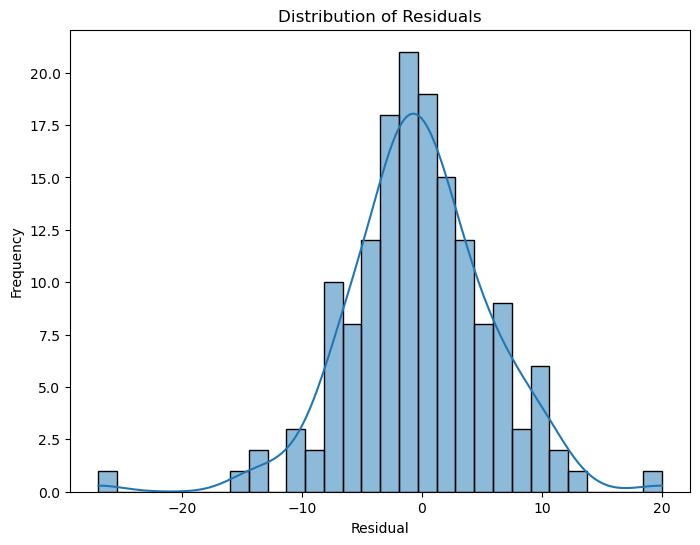

In [24]:
plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()